In [ ]:
# Load Dataset
import pandas as pd
from src.config import HDFS_DATA_DIR, FIGURES_DIR, RESULTS_DIR

hdfs_df = pd.read_csv(
    HDFS_DATA_DIR / "Event_occurrence_matrix.csv"
)

print(hdfs_df.shape)

hdfs_df.head()

(575061, 32)


,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,...,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,...,0,10,1,10,0,4,10,0,0,0
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,...,1,3,1,3,0,0,3,0,0,0
3,blk_-9073992586687739851,Success,NaN,0,3,0,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
4,blk_7854771516489510256,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0


In [2]:
# Label Distribution

hdfs_df["Label"].value_counts()

Label
Success    558223
Fail        16838
Name: count, dtype: int64

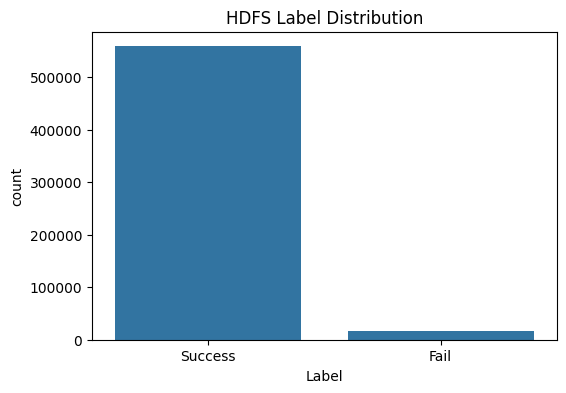

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=hdfs_df,
    x="Label"
)

plt.title(
    "HDFS Label Distribution"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "hdfs_label_distribution.png",
    dpi=300
)

plt.show()

In [4]:
# Convert labels

hdfs_df["Label"] = hdfs_df["Label"].replace({
    "Success": 0,
    "Fail": 1
})

print(
    hdfs_df["Label"].value_counts()
)

Label
0    558223
1     16838
Name: count, dtype: int64


In [5]:
hdfs_df["Label"] = hdfs_df["Label"].astype(int)

In [6]:
y = hdfs_df["Label"]

In [7]:
print(y.dtype)
print(y.unique())

int64
[0 1]


In [8]:
print(
    "Missing Labels:",
    hdfs_df["Label"].isna().sum()
)

Missing Labels: 0


In [9]:
hdfs_df["Label"].value_counts()

Label
0    558223
1     16838
Name: count, dtype: int64

In [10]:
# Feature Selection
drop_cols = [
    "BlockId",
    "Type"
]

X = hdfs_df.drop(
    columns=drop_cols + ["Label"]
)

y = hdfs_df["Label"]

print(X.shape)
print(y.shape)

(575061, 29)
(575061,)


In [11]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
# Isolation Forest

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.03,
    random_state=42
)

iso_model.fit(X_scaled)

iso_pred = iso_model.predict(X_scaled)

iso_pred = [
    1 if x==-1 else 0
    for x in iso_pred
]

In [13]:
iso_pred = [
    1 if x == -1 else 0
    for x in iso_model.predict(X_scaled)
]

iso_pred = pd.Series(iso_pred).astype(int)

In [14]:
print(iso_pred.dtype)
print(set(iso_pred))

int64
{0, 1}


In [15]:
# Evaluate

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

iso_precision = precision_score(
    y,
    iso_pred
)

iso_recall = recall_score(
    y,
    iso_pred
)

iso_f1 = f1_score(
    y,
    iso_pred
)

print(
    iso_precision,
    iso_recall,
    iso_f1
)

0.7528081417263476 0.593063309181613 0.6634554695545295


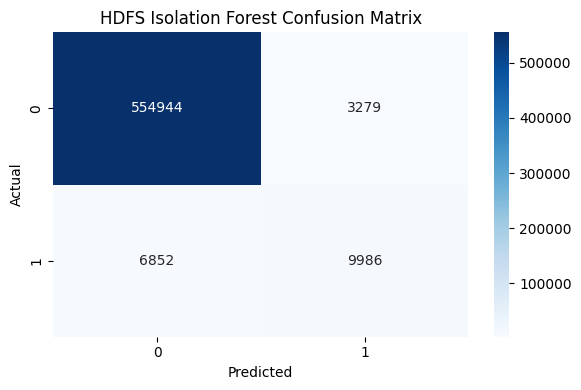

In [ ]:
# Isolation Forest Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y,
    iso_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "HDFS Isolation Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "hdfs_isolation_forest_confusion_matrix.png",
    dpi=300
)

plt.show()

In [17]:
# LOF Model

from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(
    contamination=0.0293
)

lof_pred = lof_model.fit_predict(
    X_scaled
)

lof_pred = [
    1 if x == -1 else 0
    for x in lof_pred
]

lof_pred = pd.Series(
    lof_pred
).astype(int)

d:\Mtech\Performance_Anomaly_Detection\venv\Lib\site-packages\sklearn\neighbors\_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [18]:
# LOF Evaluation

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

lof_precision = precision_score(
    y,
    lof_pred
)

lof_recall = recall_score(
    y,
    lof_pred
)

lof_f1 = f1_score(
    y,
    lof_pred
)

print("Precision:", lof_precision)
print("Recall:", lof_recall)
print("F1:", lof_f1)

Precision: 0.625
Recall: 0.04840242309062834
F1: 0.0898467644140668


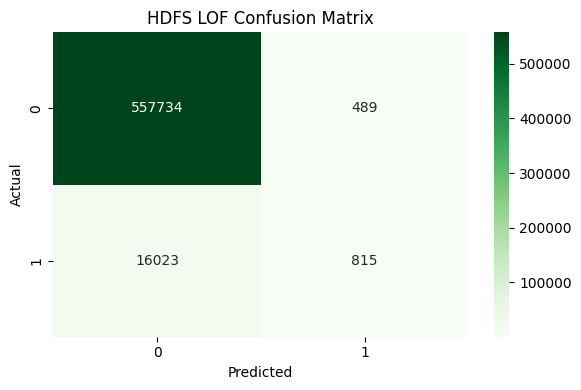

In [ ]:
# LOF Confusion Matrix
cm = confusion_matrix(
    y,
    lof_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "HDFS LOF Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "hdfs_lof_confusion_matrix.png",
    dpi=300
)

plt.show()

In [20]:
# Create HDFS Results Table

hdfs_results = pd.DataFrame({

    "Model":[
        "Isolation Forest",
        "LOF"
    ],

    "Precision":[
        iso_precision,
        lof_precision
    ],

    "Recall":[
        iso_recall,
        lof_recall
    ],

    "F1":[
        iso_f1,
        lof_f1
    ]
})

hdfs_results

,Model,Precision,Recall,F1
0,Isolation Forest,0.752808,0.593063,0.663455
1,LOF,0.625000,0.048402,0.089847


In [ ]:
# Save Results
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
hdfs_results.to_csv(
    RESULTS_DIR / "hdfs_results.csv",
    index=False
)

In [22]:
# Compare Dataset 1 vs Dataset 2

comparison = pd.DataFrame({

    "Dataset":[
        "IT Metrics",
        "IT Metrics",
        "HDFS",
        "HDFS"
    ],

    "Model":[
        "Isolation Forest",
        "LOF",
        "Isolation Forest",
        "LOF"
    ],

    "Precision":[
        0.0100,      # replace with your actual IT result
        0.0020,      # replace with your actual IT result
        iso_precision,
        lof_precision
    ],

    "Recall":[
        0.0099,
        0.0020,
        iso_recall,
        lof_recall
    ],

    "F1":[
        0.0100,
        0.0020,
        iso_f1,
        lof_f1
    ]
})

comparison

,Dataset,Model,Precision,Recall,F1
0,IT Metrics,Isolation Forest,0.010000,0.009900,0.010000
1,IT Metrics,LOF,0.002000,0.002000,0.002000
2,HDFS,Isolation Forest,0.752808,0.593063,0.663455
3,HDFS,LOF,0.625000,0.048402,0.089847


In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
comparison.to_csv(
    RESULTS_DIR / "cross_dataset_comparison.csv",
    index=False
)

In [ ]:
hdfs_results